```markdown
# 1. Installation des bibliothèques nécessaires
Nous avons besoin de `yfinance` pour obtenir des données boursières réelles facilement, en plus de `torch` et `scikit-learn`.
```

In [1]:
!pip install yfinance pandas numpy matplotlib scikit-learn torch

```markdown
# 2. Chargement et Prétraitement des données
Nous allons télécharger les données de Microsoft (MSFT) comme exemple. Nous normaliserons les prix entre 0 et 1 car les réseaux de neurones (et surtout les LSTM) sont très sensibles à l'échelle des données.
```

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Téléchargement des données
df = yf.download('MSFT', start='2020-01-01', end='2023-12-31')
data = df[['Close']].values

# Normalisation
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

# Paramètres : on regarde les 60 derniers jours pour prédire le suivant
SEQ_LENGTH = 60
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Split Train/Test (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Taille entraînement : {X_train.shape}")

/tmp/ipykernel_2427/163615013.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('MSFT', start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed

Taille entraînement : (756, 60, 1)


```markdown
# 3. Création du Dataset et DataLoader PyTorch
PyTorch utilise des `DataLoaders` pour gérer le passage des données par lots (batches) pendant l'entraînement.
```

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=32, shuffle=False)

```markdown
# 4. Définition du modèle LSTM
Nous définissons une classe qui hérite de `nn.Module`. L'architecture contient une couche LSTM, un Dropout pour éviter le surapprentissage (overfitting), et une couche linéaire pour la sortie.
```

In [4]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()
print(model)

LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


```markdown
# 5. Entraînement et Évaluation
Nous utilisons la perte MSE (Mean Squared Error) et l'optimiseur Adam.
```

Époque [1/10], Perte: 0.0127
Époque [2/10], Perte: 0.0233
Époque [3/10], Perte: 0.0036
Époque [4/10], Perte: 0.0025
Époque [5/10], Perte: 0.0013
Époque [6/10], Perte: 0.0016
Époque [7/10], Perte: 0.0020
Époque [8/10], Perte: 0.0019
Époque [9/10], Perte: 0.0012
Époque [10/10], Perte: 0.0012
Score R² sur le test set : 0.8375


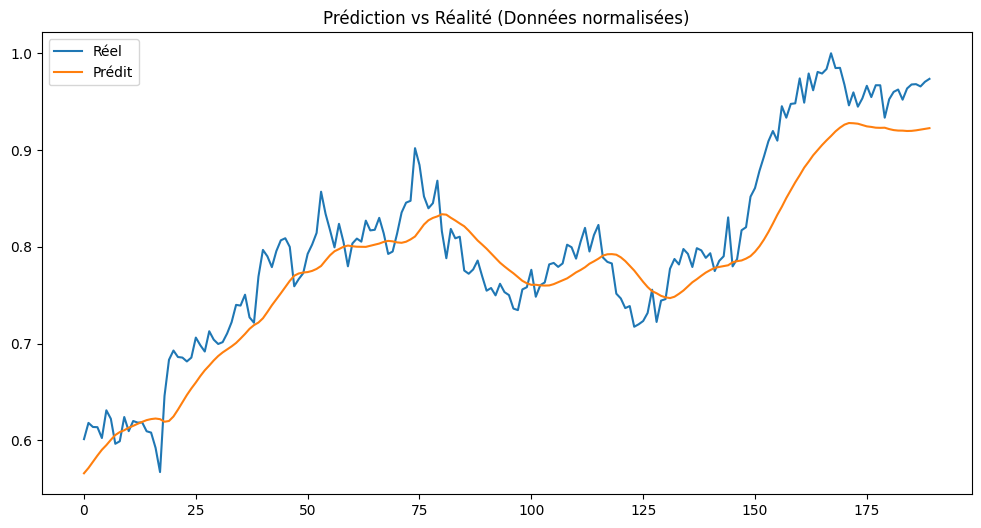

In [5]:
from sklearn.metrics import r2_score

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Boucle d'entraînement rapide (5 époques pour l'exemple)
epochs = 10
model.train()
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Époque [{epoch+1}/{epochs}], Perte: {loss.item():.4f}')

# Évaluation
model.eval()
predictions = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        preds = model(batch_X)
        predictions.append(preds.numpy())

predictions = np.concatenate(predictions)
# Calcul du R²
score = r2_score(y_test, predictions)
print(f'Score R² sur le test set : {score:.4f}')

# Visualisation
plt.figure(figsize=(12,6))
plt.plot(y_test, label='Réel')
plt.plot(predictions, label='Prédit')
plt.legend()
plt.title('Prédiction vs Réalité (Données normalisées)')
plt.show()